In [1]:
import terragon
import geopandas as gpd
from pathlib import Path
from utils import visualize_sat_images

In [2]:
# we will use the sample data to download a minicube
gdf = gpd.read_file(Path("data/TUM_OTN.geojson"))
gdf = gdf.to_crs("EPSG:32632")
arguments = dict(
    shp=gdf,
    collection="SENTINEL-1",
    start_date="2021-01-01",
    end_date="2021-01-02",
    bands=["VH"],
    resolution=10,
    download_folder="tests/download/",
    filter={"processingLevel": "GRD_HD"},
)

In [ ]:
# credentials for an NASA earth data account can be created here: https://urs.earthdata.nasa.gov/users/new
credentials = {"asf_username": "<your-username>", "asf_password": "<your-password>"}
tg = terragon.init("asf", credentials=credentials)

In [4]:
# collections can be viewed using the following command
collections = tg.retrieve_collections()
print(collections)

['AIRSAR', 'ALOS', 'ERS', 'ERS-1', 'ERS-2', 'JERS-1', 'NISAR', 'RADARSAT-1', 'SEASAT 1', 'SENTINEL-1', 'Sentinel-1A', 'Sentinel-1B', 'SIR-C', 'SMAP', 'UAVSAR']


C:\Users\hoeh_pa\terragon\terragon\alaska_satellite_facility.py:92: UserWarning: Currently we only support the following collections: ['SENTINEL-1', 'ALOS PALSAR', 'ALOS AVNIR-2']
  warnings.warn(


In [5]:
# we can now download the data, in the background we search the folder of the corresponding tile for the correct files
# the download may take a while depending on the size of the data and the number of files because ASF is not providing a STAC API
# therefore it is possible to download data with up to 4 concurrent workers
# make sure to have the right packages installed (remotezip)
ds = tg.create(**arguments, num_workers=4)
# or
# items = tg.search(**arguments, num_workers=4)
# ds = tg.download(items)
ds

["'type': 'GEOMETRY_SIMPLIFICATION': 'report': 'Shape Collapsed to Point: shape of 4 simplified to 1 with proximity threshold of 0.004'"]


<xarray.Dataset> Size: 2kB
Dimensions:      (x: 28, y: 18, time: 2)
Coordinates:
  * x            (x) float64 224B 6.976e+05 6.976e+05 ... 6.979e+05 6.979e+05
  * y            (y) float64 144B 5.326e+06 5.326e+06 ... 5.326e+06 5.326e+06
  * time         (time) datetime64[ns] 16B 2021-01-01T05:26:52 2021-01-02T05:...
    spatial_ref  int64 8B 0
Data variables:
    vh           (time, y, x) uint16 2kB 65535 65535 65535 ... 65535 65535 65535
Attributes:
    crs:          EPSG:32632
    data_source:  ASF
    collection:   SENTINEL-1

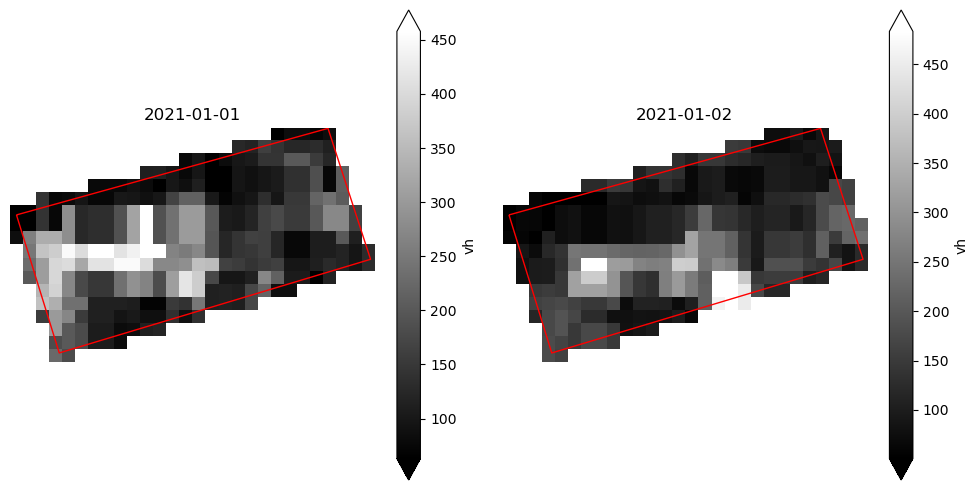

In [6]:
ds = ds.where(ds != 65535)  # remove no data values
arguments["bands"] = [band.lower() for band in arguments["bands"]]
visualize_sat_images(ds, gdf, list(reversed(arguments["bands"])))

### special arguments for cdse

In [ ]:
# downloaded tile tifs are removed by default when creating a minicube, this behavior can be change with rm_tmp_files=False
ds = tg.create(**arguments, rm_tmp_files=False)

In [ ]:
# resampling: using a different resampling method in the reprojection process - default: rasterio.enums.Resampling = rasterio.enums.Resampling.nearest
ds = tg.create(**arguments, resampling=rasterio.enums.Resampling.bilinear)